In [8]:
# download via curl
#!/bin/bash
!curl -L -o /home/jovyan/Semantic-Embedding-Evolution/data/un-general-debates.zip https://www.kaggle.com/api/v1/datasets/download/unitednations/un-general-debates

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 43.6M  100 43.6M    0     0  15.7M      0  0:00:02  0:00:02 --:--:-- 19.4M


In [9]:
!unzip /home/jovyan/Semantic-Embedding-Evolution/data/un-general-debates.zip -d /home/jovyan/Semantic-Embedding-Evolution/data/

Archive:  /home/jovyan/Semantic-Embedding-Evolution/data/un-general-debates.zip
  inflating: /home/jovyan/Semantic-Embedding-Evolution/data/un-general-debates.csv  


[UN General Debates Dataset](https://www.kaggle.com/datasets/unitednations/un-general-debates?resource=download)

This data set includes one file with the following fields:

- `Session`: the UN session. There is one session per year, and the data in this dataset ranges from session 25 to session 71.
- `Year`: The year of the session, from 25 to 71.
- `Country`: The representative’s country, as an ISO 3166 Alpha-3 country code (more information: https://www.iso.org/iso-3166-country-codes.html)
- `Text`: The complete text of that country’s statement in the general debate from that year, with OCR page numbers removed.

In [1]:
import pandas as pd

df = pd.read_csv('/home/jovyan/Semantic-Embedding-Evolution/data/un-general-debates.csv')
df['len'] = df['text'].apply(lambda x: len(x.split()))
print(f"Dataset shape: {df.shape}") 
print(f"Average document length: {df['len'].mean():.2f} words")
print(f"Estimated nr. of tokens: {df['len'].sum()/1000:.2f}K")
df.head()

Dataset shape: (7507, 5)
Average document length: 2865.47 words
Estimated nr. of tokens: 21511.08K


,session,year,country,text,len
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...,3011
1,44,1989,FIN,"﻿\nMay I begin by congratulating you. Sir, on ...",2727
2,44,1989,NER,"﻿\nMr. President, it is a particular pleasure ...",4860
3,44,1989,URY,﻿\nDuring the debate at the fortieth session o...,2711
4,44,1989,ZWE,﻿I should like at the outset to express my del...,4551


In [2]:
df['year'].min(), df['year'].max()

(1970, 2015)

In this approach, we aim to move from static embeddings (Word2Vec) to Contextualized Embeddings (BERT), which allows us to capture how a word's meaning changes based on syntax and context, not just word co-occurence as in the matrix factorization approach.

To "update semantics" with BERT for evolution analysis, the standard technique is **Diachronic Fine-Tuning** using **Masked Language Modeling (MLM)**.

**Temporal Forking**
- create 2 copies of a *base model* and evolve them separately along different timelines
    - Base: a standard pre-trained model (e.g., distilbert-base-uncased or bert-base-uncased). This contains "General English" knowledge
    - Fork: two (or more) separate training pipelines with the same starting point
        - Pipeline A (Past): Fine-tune the Base model only on UN Debates from the 1970s-1980s
        - Pipeline B (Present): Fine-tune the Base model only on UN Debates from the 1990s-2010s

- Objective: MLM, whereby the training loop randomly hides words (e.g., "The [MASK] of the Soviet Union") and learns to predict them. This forces the model to update its internal weights to match the probabilities and contexts of that specific decade.
- Comparison: We now have two models, Model_70s and Model_10s. Feeding the word "terrorism" into both we can assess whether the vectors differ significantly (more than control words), the semantics have evolved.

**Analysis**
1. Contextual Embeddings Extraction
Contextual Extraction: Feeding the same neutral sentences to both models and compare the output vectors for the target word.
    - Input: "The amazon is a massive entity."
    - Model_70s: Sees "entity" and thinks "river/forest" (contextual weights pull towards nature).
    - Model_10s: Sees "entity" and thinks "corporation" (contextual weights pull towards business).

2. Static Layer Extraction
Transformers have an initial "Word Embedding" layer before the transformer blocks. Fine-tuning updates this layer too.
    -  Extract these raw vectors just like Word2Vec to see how the "base definition" of the word changed, independent of context.
    -  Compare these static vectors across the two models.

In [3]:
!pip install tf-keras datasets transformers[torch]

  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached datasets-4.4.2-py3-none-any.whl.metadata (19 kB)
  Using cached xxhash-3.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py311-none-any.whl.metadata (7.5 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)
Using cached datasets-4.4.2-py3-none-any.whl (512 kB)
Using cached multiprocess-0.70.18-py311-none-any.whl (144 kB)
Using cached accelerate-1.12.0-py3-none-any.whl (380 kB)
Using cached xxhash-3.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (193 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [tf-keras]4/5 [tf-keras]e]


In [4]:
!pip install "accelerate>=0.26.0"

In [10]:
import pandas as pd
import torch
import numpy as np
from scipy.spatial.distance import cosine
from transformers import (
    AutoTokenizer, 
    AutoModelForMaskedLM, 
    DataCollatorForLanguageModeling, 
    Trainer, 
    TrainingArguments
)
from datasets import Dataset

# Configuration
DATA_PATH = "/home/jovyan/Semantic-Embedding-Evolution/data/un-general-debates.csv"
BASE_MODEL = "distilbert-base-uncased"
SEQ_LEN = 128
BATCH_SIZE = 16

# Data Loading and Splitting
df = pd.read_csv(DATA_PATH)
df_past = df[(df['year'] >= 1970) & (df['year'] <= 1989)]
df_present = df[(df['year'] >= 1990) & (df['year'] <= 2016)]

datasets = {
    "Past": Dataset.from_pandas(df_past[['text']]),
    "Present": Dataset.from_pandas(df_present[['text']])
}

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        truncation=True, 
        padding="max_length", 
        max_length=SEQ_LEN
    )

tokenized_datasets = {}
for era, ds in datasets.items():
    tokenized_datasets[era] = ds.map(tokenize_function, batched=True, remove_columns=["text"])

# Fine-Tuning Loop (Temporal Forking)
trained_model_paths = {}

for era, dataset in tokenized_datasets.items():
    # --- TEMPORAL FORKING START ---
    # We reload the base model from scratch for each era.
    # This ensures both timelines start from the exact same "General English" state
    # and evolve purely based on the specific decade's data.
    model = AutoModelForMaskedLM.from_pretrained(BASE_MODEL)
    
    # Masked Language Modeling (MLM) setup
    # The collator dynamically masks 15% of tokens in each batch.
    # The model must predict the original word, forcing it to learn 
    # the co-occurrence patterns and syntax of the specific era.
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer, 
        mlm=True, 
        mlm_probability=0.15
    )
    
    training_args = TrainingArguments(
        output_dir=f"./results_{era}",
        per_device_train_batch_size=BATCH_SIZE,
        num_train_epochs=6,  # Increased from 3 to allow more divergence
        learning_rate=5e-5,  # Increased from 2e-5
        weight_decay=0.01,
        save_strategy="no",  # Save space, we only need the final model
        logging_steps=500
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        data_collator=data_collator,
    )
    
    print(f"Forking timeline: Fine-tuning {era} model...")
    trainer.train()
    
    save_path = f"./model_{era.lower()}"
    trainer.save_model(save_path)
    trained_model_paths[era] = save_path
    # --- TEMPORAL FORKING END ---

Map:   0%|          | 0/2730 [00:00<?, ? examples/s]

Map:   0%|          | 0/4777 [00:00<?, ? examples/s]

Forking timeline: Fine-tuning Past model...


Step,Training Loss
500,1.474900
1000,1.195100


Forking timeline: Fine-tuning Present model...


Step,Training Loss
500,1.435700
1000,1.188000
1500,1.116800


In [15]:

# Analysis 1: Contextual Embeddings Extraction
def get_contextual_embedding(text, target_word, model_path):
    local_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    local_model = AutoModelForMaskedLM.from_pretrained(model_path, output_hidden_states=True)
    local_model.eval()
    
    inputs = local_tokenizer(text, return_tensors="pt")
    
    # Find index of the target word token
    target_token_id = local_tokenizer.encode(target_word, add_special_tokens=False)[0]
    try:
        token_index = (inputs.input_ids[0] == target_token_id).nonzero(as_tuple=True)[0].item()
    except IndexError:
        print(f"Word '{target_word}' not found or split into multiple subwords.")
        return None

    with torch.no_grad():
        outputs = local_model(**inputs)
    
    # Extract hidden state from the last layer for the specific token
    last_layer_index = -1
    # Shape: [1, Sequence_Length, Hidden_Size]
    return outputs.hidden_states[last_layer_index][0, token_index].numpy()

target_sentence = "The amazon is a massive entity."
target_word = "amazon"

vec_past = get_contextual_embedding(target_sentence, target_word, trained_model_paths["Past"])
vec_present = get_contextual_embedding(target_sentence, target_word, trained_model_paths["Present"])

if vec_past is not None and vec_present is not None:
    contextual_drift = cosine(vec_past, vec_present)
    print(f"Contextual Drift for '{target_word}' in '{target_sentence}': {contextual_drift:.4f}")


Contextual Drift for 'amazon' in 'The amazon is a massive entity.': 0.0335


In [16]:
# Analysis 2: Static Layer Extraction
def get_static_embedding(word, model_path):
    local_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    local_model = AutoModelForMaskedLM.from_pretrained(model_path)
    
    token_id = local_tokenizer.encode(word, add_special_tokens=False)[0]
    
    # Access the raw non-contextual embedding matrix
    # distilbert.embeddings.word_embeddings
    word_embeddings = local_model.distilbert.embeddings.word_embeddings.weight
    
    return word_embeddings[token_id].detach().numpy()

word_to_check = "terrorism"

static_past = get_static_embedding(word_to_check, trained_model_paths["Past"])
static_present = get_static_embedding(word_to_check, trained_model_paths["Present"])

static_drift = cosine(static_past, static_present)
print(f"Static Embedding Drift for '{word_to_check}': {static_drift:.4f}")

Static Embedding Drift for 'terrorism': 0.0007



--- 1. GLOBAL DRIFT ANALYSIS (Static Layer) ---
Top 20 Words with Largest Semantic Shift:
adam: 0.0147
hamilton: 0.0144
2015: 0.0124
2005: 0.0107
2001: 0.0098
movie: 0.0098
television: 0.0097
moon: 0.0094
creature: 0.0092
1980: 0.0081
swiss: 0.0081
cain: 0.0079
allen: 0.0078
complexes: 0.0078
chemical: 0.0077
centre: 0.0077
institute: 0.0076
switzerland: 0.0076
county: 0.0075
cool: 0.0075

--- 2. VISUALIZATION: Static Drift Vector Field ---


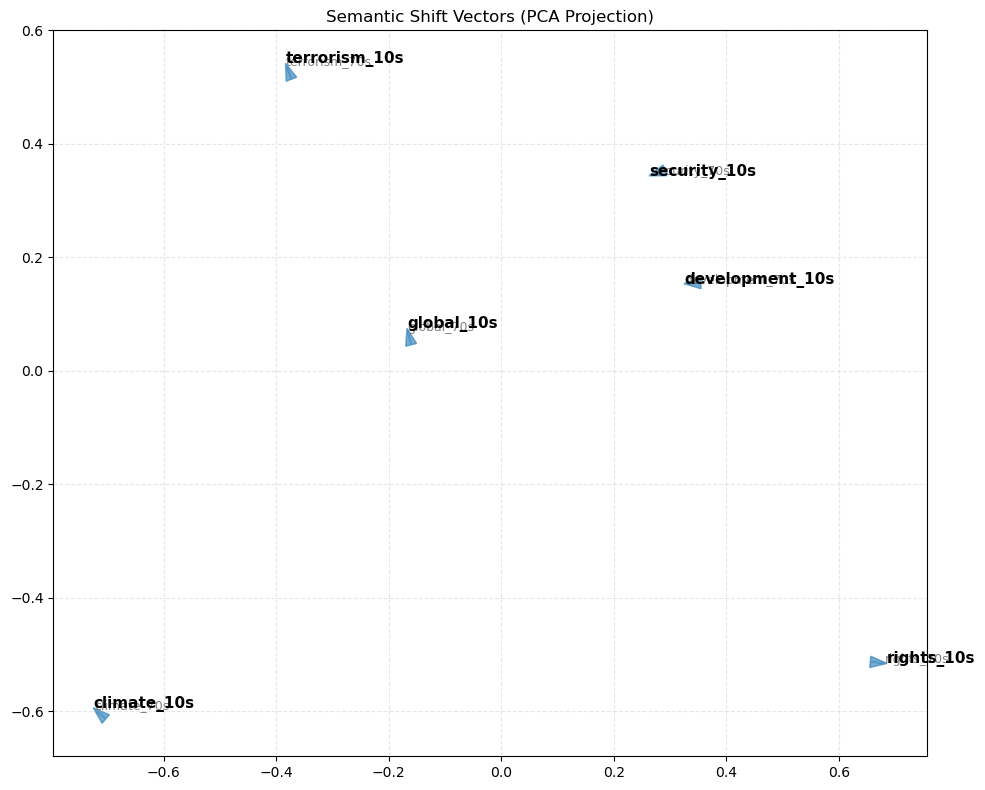


--- 3. VISUALIZATION: Contextual Point Clouds ---
Sampling contexts for 'freedom'...


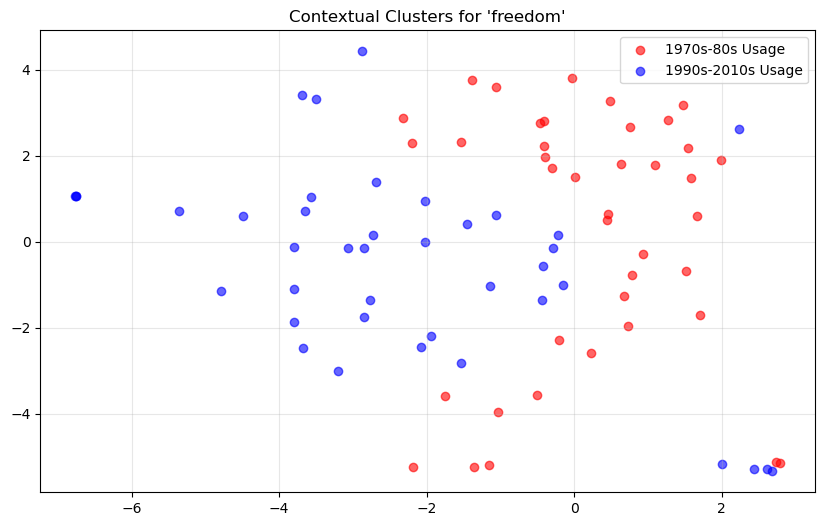

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
# ==========================================
# EXTENSIVE ANALYSIS & VISUALIZATION
# ==========================================

print("\n--- 1. GLOBAL DRIFT ANALYSIS (Static Layer) ---")

def get_static_weights(model_path):
    model = AutoModelForMaskedLM.from_pretrained(model_path)
    # Extract the raw embedding matrix (Vocab Size x Hidden Dim)
    return model.distilbert.embeddings.word_embeddings.weight.detach().cpu()

# Load weights
W_past = get_static_weights(trained_model_paths["Past"])
W_present = get_static_weights(trained_model_paths["Present"])

# Calculate Cosine Distance for entire vocab efficiently
# Normalize first to use dot product
W_past_norm = torch.nn.functional.normalize(W_past, p=2, dim=1)
W_present_norm = torch.nn.functional.normalize(W_present, p=2, dim=1)

# Cosine similarity = dot product of normalized vectors
cosine_sims = (W_past_norm * W_present_norm).sum(dim=1)
drifts = 1 - cosine_sims

# Get top changed words (filtering out subwords '##' and special tokens)
top_indices = torch.argsort(drifts, descending=True)
count = 0
print("Top 20 Words with Largest Semantic Shift:")
for idx in top_indices:
    word = tokenizer.decode([idx])
    # Filter out subwords (##), unused tokens ([unused]), and special chars
    if not word.startswith("##") and "[" not in word and len(word) > 2:
        print(f"{word}: {drifts[idx]:.4f}")
        count += 1
    if count >= 20:
        break

print("\n--- 2. VISUALIZATION: Static Drift Vector Field ---")

def plot_static_drift_arrows(words_to_plot):
    # Get IDs
    ids = [tokenizer.encode(w, add_special_tokens=False)[0] for w in words_to_plot]
    
    # Get vectors
    vecs_past = W_past[ids].numpy()
    vecs_present = W_present[ids].numpy()
    
    # Use PCA to project to 2D (fit on both past and present to share space)
    combined = np.vstack([vecs_past, vecs_present])
    pca = PCA(n_components=2)
    pca.fit(combined)
    
    coords_past = pca.transform(vecs_past)
    coords_present = pca.transform(vecs_present)
    
    plt.figure(figsize=(10, 8))
    plt.title("Semantic Shift Vectors (PCA Projection)")
    
    for i, word in enumerate(words_to_plot):
        # Plot Arrow
        plt.arrow(
            coords_past[i, 0], coords_past[i, 1],
            coords_present[i, 0] - coords_past[i, 0],
            coords_present[i, 1] - coords_past[i, 1],
            head_width=0.02, length_includes_head=True, color='tab:blue', alpha=0.6
        )
        # Label Start (Past) and End (Present)
        plt.text(coords_past[i, 0], coords_past[i, 1], word + "_70s", fontsize=9, color='gray')
        plt.text(coords_present[i, 0], coords_present[i, 1], word + "_10s", fontsize=11, weight='bold')
        
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize interesting diplomatic words
interesting_words = ["terrorism", "rights", "development", "climate", "security", "global"]
plot_static_drift_arrows(interesting_words)


print("\n--- 3. VISUALIZATION: Contextual Point Clouds ---")

def plot_contextual_cloud(target_word, n_samples=50):
    # Helper to extract contextual embeddings from N sentences
    def get_embeddings_for_word(text_series, model_path, word, limit):
        local_model = AutoModelForMaskedLM.from_pretrained(model_path, output_hidden_states=True)
        local_model.eval()
        embeddings = []
        found_count = 0
        
        target_id = tokenizer.encode(word, add_special_tokens=False)[0]
        
        for text in text_series:
            if found_count >= limit: break
            if word not in text.lower(): continue
            
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
            try:
                # Find index of word
                idx = (inputs.input_ids[0] == target_id).nonzero(as_tuple=True)[0].item()
                with torch.no_grad():
                    out = local_model(**inputs)
                # Last layer hidden state
                emb = out.hidden_states[-1][0, idx].numpy()
                embeddings.append(emb)
                found_count += 1
            except:
                continue
        return np.array(embeddings)

    print(f"Sampling contexts for '{target_word}'...")
    embs_past = get_embeddings_for_word(df_past['text'], trained_model_paths["Past"], target_word, n_samples)
    embs_present = get_embeddings_for_word(df_present['text'], trained_model_paths["Present"], target_word, n_samples)
    
    if len(embs_past) < 5 or len(embs_present) < 5:
        print("Not enough samples found.")
        return

    # t-SNE Projection
    combined = np.vstack([embs_past, embs_present])
    tsne = TSNE(n_components=2, perplexity=min(30, len(combined)-1), random_state=42)
    projections = tsne.fit_transform(combined)
    
    # Split back
    proj_past = projections[:len(embs_past)]
    proj_present = projections[len(embs_past):]
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(proj_past[:, 0], proj_past[:, 1], c='red', alpha=0.6, label='1970s-80s Usage')
    plt.scatter(proj_present[:, 0], proj_present[:, 1], c='blue', alpha=0.6, label='1990s-2010s Usage')
    plt.title(f"Contextual Clusters for '{target_word}'")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run for a word likely to change meaning/usage
plot_contextual_cloud("freedom", n_samples=40)


--- LOADING MODELS & WEIGHTS ---

--- 1. DIAGNOSTIC: BASELINE MOVEMENT ---
Avg Drift (Past vs Base): 0.00169
Avg Drift (Present vs Base): 0.00216

--- 2. FREQUENCY-WEIGHTED DRIFT ANALYSIS ---
Counting word frequencies...


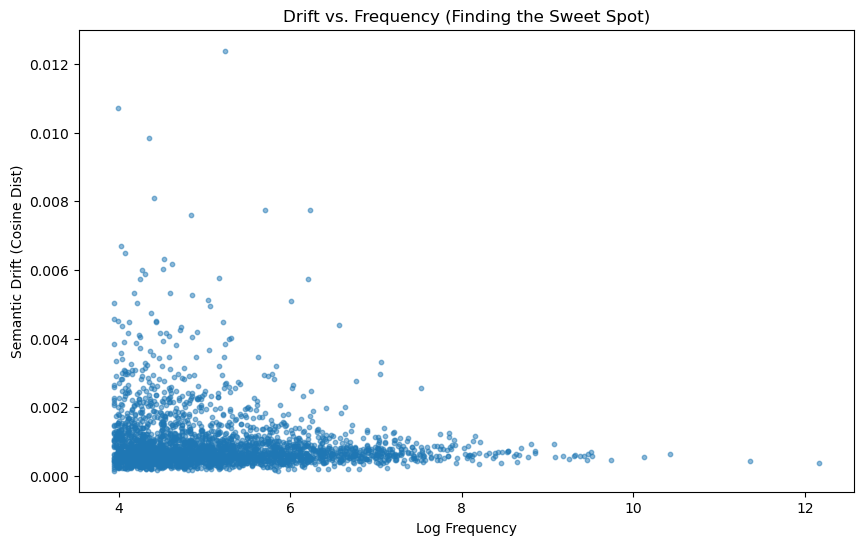

Top 20 Frequent Words with Largest Shift:
2015: 0.0124
2005: 0.0107
2001: 0.0098
swiss: 0.0081
chemical: 0.0077
centre: 0.0077
switzerland: 0.0076
jan: 0.0067
soldiers: 0.0065
1992: 0.0063
green: 0.0062
georgia: 0.0060
agency: 0.0060
release: 0.0059
infrastructure: 0.0058
terrorist: 0.0057
woods: 0.0057
network: 0.0053
defined: 0.0053
rome: 0.0053

--- 3. QUALITATIVE: NEAREST NEIGHBORS ---
WORD            | PAST NEIGHBORS                           | PRESENT NEIGHBORS                       
----------------------------------------------------------------------------------------------------
terrorism       | terrorist, terrorists, insurgency, militants, narcotics | terrorists, terrorist, insurgency, militants, narcotics
climate         | climates, climatic, temperature, temperatures, environment | climates, climatic, temperatures, temperature, environmentally
development     | develop, developing, developments, developed, developmental | developing, develop, developments, developed, deve

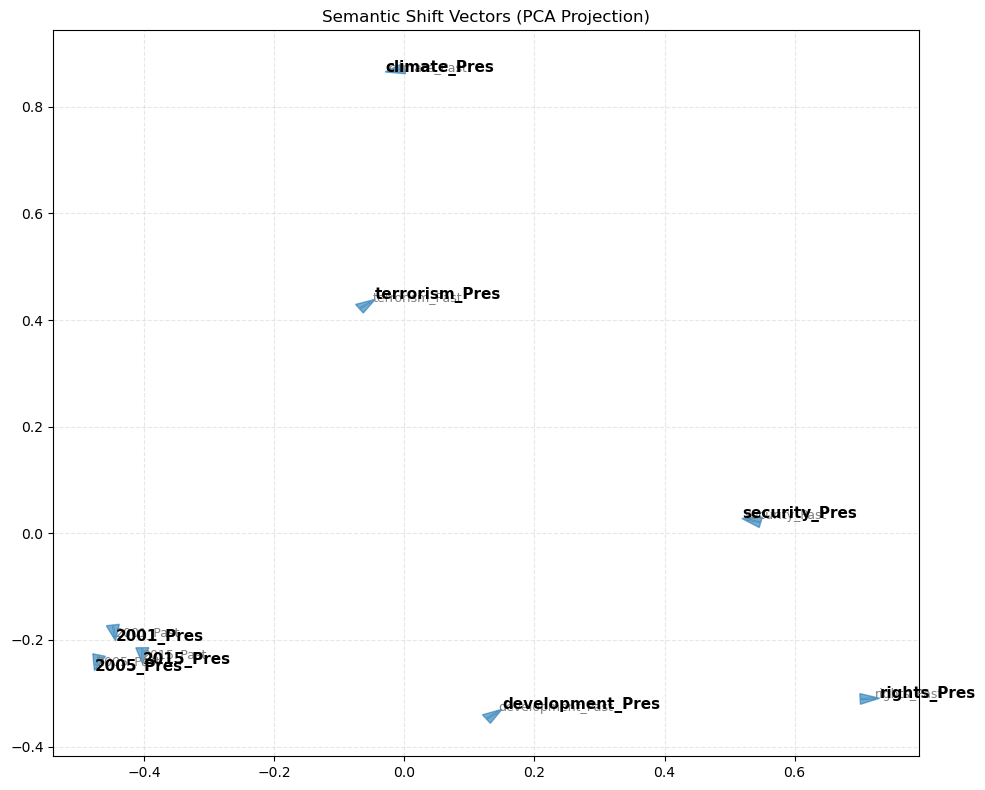

In [18]:
from collections import Counter
# ==========================================
# EXTENSIVE ANALYSIS & VISUALIZATION
# ==========================================

print("\n--- LOADING MODELS & WEIGHTS ---")

def get_static_weights(model_path):
    model = AutoModelForMaskedLM.from_pretrained(model_path)
    return model.distilbert.embeddings.word_embeddings.weight.detach().cpu()

# Load weights
W_past = get_static_weights(trained_model_paths["Past"])
W_present = get_static_weights(trained_model_paths["Present"])
W_base = get_static_weights(BASE_MODEL) # Control: Original Pre-trained weights

# Normalize
W_past_norm = torch.nn.functional.normalize(W_past, p=2, dim=1)
W_present_norm = torch.nn.functional.normalize(W_present, p=2, dim=1)
W_base_norm = torch.nn.functional.normalize(W_base, p=2, dim=1)

print("\n--- 1. DIAGNOSTIC: BASELINE MOVEMENT ---")
# Check if models actually moved from the original BERT
drift_from_base_past = 1 - (W_past_norm * W_base_norm).sum(dim=1).mean().item()
drift_from_base_present = 1 - (W_present_norm * W_base_norm).sum(dim=1).mean().item()

print(f"Avg Drift (Past vs Base): {drift_from_base_past:.5f}")
print(f"Avg Drift (Present vs Base): {drift_from_base_present:.5f}")
if drift_from_base_past < 0.001:
    print("WARNING: Models haven't moved much from Base. Consider increasing Learning Rate or Epochs.")

print("\n--- 2. FREQUENCY-WEIGHTED DRIFT ANALYSIS ---")

# Calculate global drift
cosine_sims = (W_past_norm * W_present_norm).sum(dim=1)
drifts = 1 - cosine_sims

# Count word frequencies to filter noise
# (We count in 'Present' corpus as a proxy for general relevance)
print("Counting word frequencies...")
all_text = " ".join(df_present['text'].tolist()[:1000]) # Sample for speed
word_counts = Counter(all_text.lower().split())

vocab_freqs = []
vocab_drifts = []
valid_indices = []

for idx, drift in enumerate(drifts):
    word = tokenizer.decode([idx]).strip()
    # Filter: must be a real word, no subwords (##), no special tokens
    if not word.startswith("##") and "[" not in word and len(word) > 2:
        freq = word_counts.get(word, 0)
        if freq > 50: # Only consider frequent words
            vocab_freqs.append(freq)
            vocab_drifts.append(drift.item())
            valid_indices.append((word, drift.item(), idx))

# Plot Drift vs Frequency
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(vocab_freqs), vocab_drifts, alpha=0.5, s=10)
plt.xlabel("Log Frequency")
plt.ylabel("Semantic Drift (Cosine Dist)")
plt.title("Drift vs. Frequency (Finding the Sweet Spot)")
plt.show()

# Print Top Drifters (Filtered by frequency)
# Sort by drift score
valid_indices.sort(key=lambda x: x[1], reverse=True)

print("Top 20 Frequent Words with Largest Shift:")
for word, drift, idx in valid_indices[:20]:
    print(f"{word}: {drift:.4f}")

print("\n--- 3. QUALITATIVE: NEAREST NEIGHBORS ---")

def get_neighbors(target_word, w_matrix, k=5):
    target_id = tokenizer.encode(target_word, add_special_tokens=False)[0]
    target_vec = w_matrix[target_id].unsqueeze(0) # 1 x Dim
    
    # Calculate cosine sim to all words
    # w_matrix is already normalized? No, passed in arg might not be.
    # Let's assume w_matrix is the normalized version for speed
    sims = torch.mm(target_vec, w_matrix.t()).squeeze()
    
    top_k_ids = torch.topk(sims, k+1).indices.tolist() # +1 because word itself is top
    neighbors = []
    for idx in top_k_ids:
        if idx != target_id:
            neighbors.append(tokenizer.decode([idx]))
    return neighbors[:k]

targets = ["terrorism", "climate", "development", "security", "rights"]

print(f"{'WORD':<15} | {'PAST NEIGHBORS':<40} | {'PRESENT NEIGHBORS':<40}")
print("-" * 100)

for t in targets:
    try:
        n_past = get_neighbors(t, W_past_norm)
        n_present = get_neighbors(t, W_present_norm)
        print(f"{t:<15} | {', '.join(n_past):<40} | {', '.join(n_present):<40}")
    except Exception as e:
        print(f"Could not find neighbors for {t}: {e}")

print("\n--- 4. VISUALIZATION: Static Drift Vector Field ---")

def plot_static_drift_arrows(words_to_plot):
    # Get IDs
    ids = [tokenizer.encode(w, add_special_tokens=False)[0] for w in words_to_plot]
    
    # Get vectors
    vecs_past = W_past[ids].numpy()
    vecs_present = W_present[ids].numpy()
    
    # Use PCA to project to 2D
    combined = np.vstack([vecs_past, vecs_present])
    pca = PCA(n_components=2)
    pca.fit(combined)
    
    coords_past = pca.transform(vecs_past)
    coords_present = pca.transform(vecs_present)
    
    plt.figure(figsize=(10, 8))
    plt.title("Semantic Shift Vectors (PCA Projection)")
    
    for i, word in enumerate(words_to_plot):
        plt.arrow(
            coords_past[i, 0], coords_past[i, 1],
            coords_present[i, 0] - coords_past[i, 0],
            coords_present[i, 1] - coords_past[i, 1],
            head_width=0.02, length_includes_head=True, color='tab:blue', alpha=0.6
        )
        plt.text(coords_past[i, 0], coords_past[i, 1], word + "_Past", fontsize=9, color='gray')
        plt.text(coords_present[i, 0], coords_present[i, 1], word + "_Pres", fontsize=11, weight='bold')
        
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Extract just the word strings from the valid_indices tuples
top_drifter_words = [v[0] for v in valid_indices[:3]]
plot_static_drift_arrows(targets + top_drifter_words)